In [1]:
# ── Imports ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Rescaling
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Libraries loaded!")

I0000 00:00:1779832389.930717  148404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779832390.087039  148404 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779832391.459005  148404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Libraries loaded!


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)


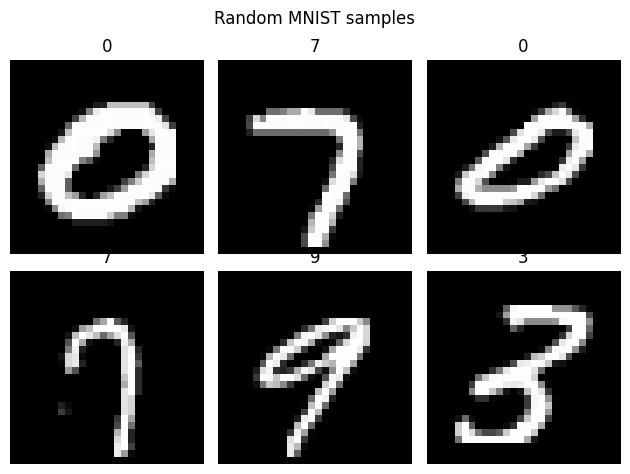

In [2]:
# ── Load MNIST dataset ─────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"X_train shape: {X_train.shape}")  # (60000, 28, 28)
print(f"y_train shape: {y_train.shape}")  # (60000,)

# Show 6 random images
for j, i in enumerate(np.random.choice(np.arange(0, len(y_train)), size=6)):
    plt.subplot(2, 3, j + 1)
    plt.axis('off')
    plt.imshow(X_train[i], cmap='gray')
    plt.title(str(y_train[i]))
plt.suptitle('Random MNIST samples')
plt.tight_layout()
plt.show()

In [3]:
# ── Preprocessing ──────────────────────────────────────────────
# Flatten: (60000, 28, 28) → (60000, 784)
X_train_flat = X_train.reshape([-1, 28 * 28])
X_test_flat  = X_test.reshape([-1, 28 * 28])

# One-Hot Encoding for Neural Network
y_train_enc = to_categorical(y_train)  # (60000, 10)
y_test_enc  = to_categorical(y_test)   # (10000, 10)

num_pixels  = X_train_flat.shape[1]    # 784
num_classes = y_train_enc.shape[1]     # 10

print(f"Flattened: {X_train_flat.shape}")
print(f"One-hot y: {y_train_enc.shape}")

Flattened: (60000, 784)
One-hot y: (60000, 10)


In [4]:
# ── Random Forest baseline (from notes) ───────────────────────
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
rf.fit(X_train_flat, y_train)

y_pred_rf = rf.predict(X_test_flat)
print(f"Random Forest Accuracy: {rf.score(X_test_flat, y_test):.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9705
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [8]:
# ── Neural Network (fixed for Keras modern) ───────────────────
from tensorflow.keras.layers import Input

model_mnist = Sequential([
    Input(shape=(num_pixels,)),        # explicit Input layer
    Rescaling(1. / 255),               # normalize 0-255 → 0-1
    Dense(units=20, activation='relu', kernel_initializer='normal'),
    Dense(units=num_classes, activation='softmax', kernel_initializer='normal')
])

model_mnist.summary()

I0000 00:00:1779832647.688090  148404 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4568 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ── Compile ────────────────────────────────────────────────────
model_mnist.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("Model compiled!")

Model compiled!


In [10]:
# ── Train ──────────────────────────────────────────────────────
history_mnist = model_mnist.fit(
    X_train_flat, y_train_enc,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20


I0000 00:00:1779832672.376266  150239 service.cc:153] XLA service 0x7fba1402f120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779832672.376297  150239 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779832673.371895  150239 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779832674.135402  150239 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779832674.306526  150239 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1011__.16
I0000 00:00:1779832676.634855  150239 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7888 - loss: 0.8030 - val_accuracy: 0.9032 - val_loss: 0.3515
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9059 - loss: 0.3350 - val_accuracy: 0.9195 - val_loss: 0.2863
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9182 - loss: 0.2848 - val_accuracy: 0.9275 - val_loss: 0.2574
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9272 - loss: 0.2538 - val_accuracy: 0.9333 - val_loss: 0.2363
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9333 - loss: 0.2319 - val_accuracy: 0.9391 - val_loss: 0.2222
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9384 - loss: 0.2160 - val_accuracy: 0.9408 - val_loss: 0.2110
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9410 - loss: 0.2035 - val_accuracy: 0.9414 - val_loss: 0.2061
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9443 - loss: 0.1921 - val_accuracy: 0.9452 - val_

In [11]:
# ── Evaluate ───────────────────────────────────────────────────
test_loss, test_acc = model_mnist.evaluate(X_test_flat, y_test_enc, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred_nn = np.argmax(model_mnist.predict(X_test_flat), axis=1)
print(classification_report(y_test, y_pred_nn))

Test accuracy: 0.9535
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.94      0.96      0.95      1032
           3       0.95      0.93      0.94      1010
           4       0.95      0.95      0.95       982
           5       0.94      0.92      0.93       892
           6       0.96      0.96      0.96       958
           7       0.96      0.95      0.95      1028
           8       0.94      0.94      0.94       974
           9       0.95      0.94      0.95      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



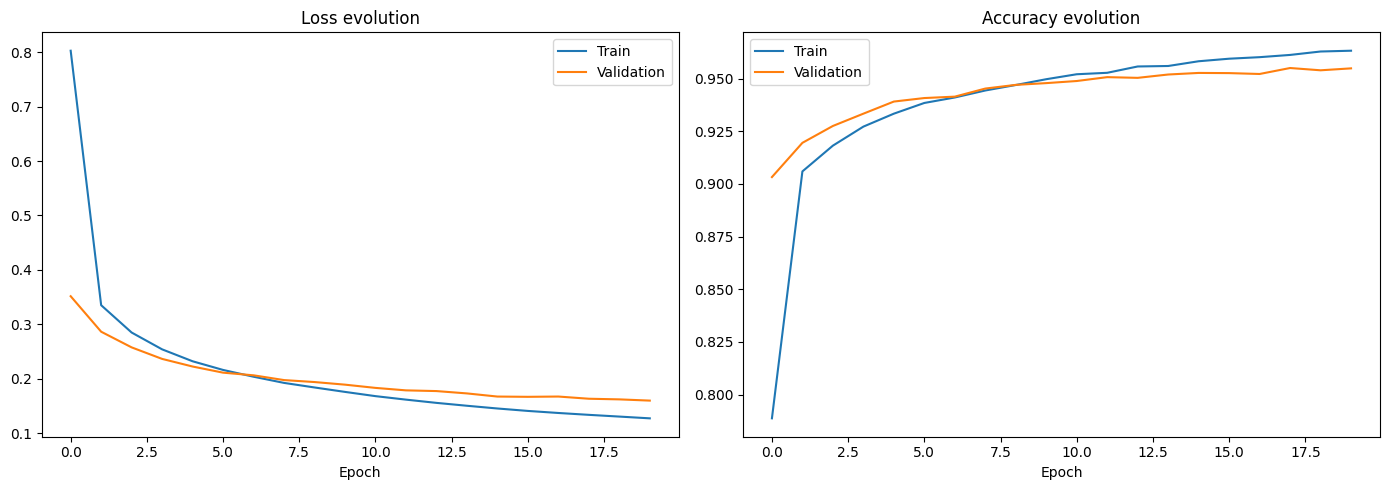

In [12]:
# ── Learning curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mnist.history['loss'],         label='Train')
axes[0].plot(history_mnist.history['val_loss'],     label='Validation')
axes[0].set_title('Loss evolution')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_mnist.history['accuracy'],     label='Train')
axes[1].plot(history_mnist.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy evolution')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

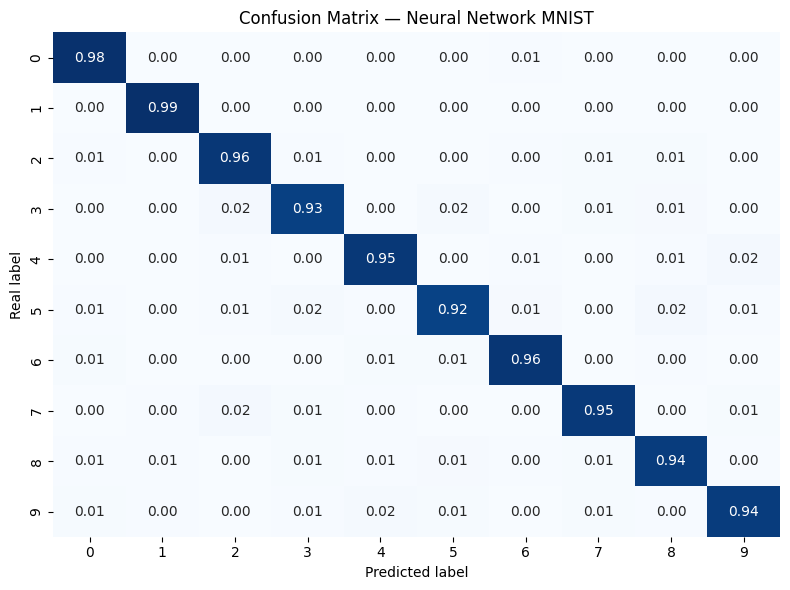

In [14]:
# ── Confusion matrix ───────────────────────────────────────────
cnf = confusion_matrix(y_test, y_pred_nn, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cnf, cmap='Blues', annot=True, fmt='.2f', cbar=False)
plt.ylabel('Real label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix — Neural Network MNIST')
plt.tight_layout()
plt.show()

In [16]:
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import category_encoders as ce
from sklearn.base import BaseEstimator, TransformerMixin

data_path = Path("/mnt/e/Users/KilianAT/Documents/Estudios/Weiterbildung/Data Science/Proyecto/mle_liora_london_firefighter/data")

# Load pre-encoding dataset
df = pd.read_csv(data_path / "dataset_pre_encoding.csv")

# Same split as modeling notebook
TARGET    = "AttendanceTimeSeconds"
DROP_COLS = ["index", "IncidentNumber", "avg_speed", "PumpOrder"]

train_df = df[df["CalYear"] <= 2023].copy()
val_df   = df[df["CalYear"] >= 2025].copy()

def get_data(data):
    to_drop = [TARGET] + DROP_COLS
    X = data.drop(columns=[c for c in to_drop if c in data.columns])
    y = data[TARGET]
    return X, y

X_train, y_train = get_data(train_df)
X_val,   y_val   = get_data(val_df)

print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")
print(f"y_train: {y_train.shape} | y_val: {y_val.shape}")

X_train: (310660, 21) | X_val: (137825, 21)
y_train: (310660,) | y_val: (137825,)


In [18]:
# EncodingTransformer must be defined before loading the Pipeline
feature_config = {
    "Month":             {"encoding": "CYCLIC"},
    "Weekday":           {"encoding": "CYCLIC"},
    "Hour":              {"encoding": "CYCLIC"},
    "CalYear":           {"encoding": "NUMERIC_KEEP"},
    "Is_Nightshift":     {"encoding": "BINARY_KEEP"},
    "Is_Rush_Hour":      {"encoding": "BINARY_KEEP"},
    "Is_Weekend":        {"encoding": "BINARY_KEEP"},
    "Is_Public_Holiday": {"encoding": "BINARY_KEEP"},
    "Is_SpecialService": {"encoding": "BINARY_KEEP"},
    "Is_RepeatedCall":   {"encoding": "BINARY_KEEP"},
    "Is_central_London": {"encoding": "BINARY_KEEP"},
    "Latitude":          {"encoding": "NUMERIC_KEEP"},
    "Longitude":         {"encoding": "NUMERIC_KEEP"},
    "distance_fire_to_station": {"encoding": "NUMERIC_KEEP"},
    "IncidentGroup":     {"encoding": "ONE_HOT"},
    "PropertyCategory":  {"encoding": "ONE_HOT"},
    "NumOfCalls_bucket": {"encoding": "ONE_HOT"},
    "SpecialServiceType":{"encoding": "TOP_N_PLUS_ONE_HOT", "top_n": 10},
    "DeployedFromStation_Name": {"encoding": "LEAVE_ONE_OUT_TARGET"},
    "PropertyType":      {"encoding": "LEAVE_ONE_OUT_TARGET"},
    "IncGeo_BoroughName":{"encoding": "LEAVE_ONE_OUT_TARGET"}
}

class EncodingTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, config=None):
        self.config = config or feature_config
        self.fitted_encoders_ = {}

    def fit(self, X, y=None):
        self.fitted_encoders_ = {}
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        for col, cfg in self.config.items():
            if col not in X.columns:
                continue
            method = cfg["encoding"]
            if method in ["ONE_HOT", "TOP_N_PLUS_ONE_HOT"]:
                data_to_fit = X[[col]].copy()
                top_n_list = None
                if method == "TOP_N_PLUS_ONE_HOT":
                    top_n_list = X[col].value_counts().head(cfg.get("top_n", 10)).index.tolist()
                    data_to_fit[col] = data_to_fit[col].where(data_to_fit[col].isin(top_n_list), "Other")
                enc = ce.OneHotEncoder(cols=[col], use_cat_names=True).fit(data_to_fit)
                self.fitted_encoders_[col] = (enc, top_n_list)
            elif method == "LEAVE_ONE_OUT_TARGET":
                enc = ce.LeaveOneOutEncoder(cols=[col]).fit(X[[col]], y)
                self.fitted_encoders_[col] = enc
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        encoded_parts = []
        for col, cfg in self.config.items():
            if col not in X.columns:
                continue
            method = cfg["encoding"]
            if method in ["NUMERIC_KEEP", "BINARY_KEEP"]:
                encoded_parts.append(X[[col]])
            elif method == "CYCLIC":
                periods = {"Month": 12, "Weekday": 7, "Hour": 24}
                p = periods[col]
                encoded_parts.append(pd.DataFrame({
                    f"{col}_sin": np.sin(2 * np.pi * X[col] / p),
                    f"{col}_cos": np.cos(2 * np.pi * X[col] / p)
                }, index=X.index))
            elif method in ["ONE_HOT", "TOP_N_PLUS_ONE_HOT"]:
                enc, top_n_list = self.fitted_encoders_[col]
                data_to_transform = X[[col]].copy()
                if top_n_list:
                    data_to_transform[col] = data_to_transform[col].where(
                        data_to_transform[col].isin(top_n_list), "Other"
                    )
                encoded_parts.append(enc.transform(data_to_transform))
            elif method == "LEAVE_ONE_OUT_TARGET":
                encoded_parts.append(self.fitted_encoders_[col].transform(X[[col]]))
        return pd.concat(encoded_parts, axis=1).reset_index(drop=True).values

print("EncodingTransformer defined!")

EncodingTransformer defined!


In [19]:
# Load best model pipeline
best_model = joblib.load(data_path / "best_model.pkl")
print("Best model loaded!")

Best model loaded!


In [20]:
# Final evaluation on validation set — only done ONCE
y_pred_val = best_model.predict(X_val)

print("=" * 55)
print("FINAL MODEL: XGBoost (RandomizedSearch)")
print("Evaluated on VALIDATION SET (2025-2026) — done once")
print("=" * 55)
print(f"  R²:   {r2_score(y_val, y_pred_val):.4f}")
print(f"  MAE:  {mean_absolute_error(y_val, y_pred_val):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val)):.4f}")

print("\nComparison test vs validation:")
print(f"  Test set (2024):        R²=0.5845 | MAE=50.31 | RMSE=70.66")
print(f"  Validation (2025-26):   R²={r2_score(y_val, y_pred_val):.4f} | MAE={mean_absolute_error(y_val, y_pred_val):.4f} | RMSE={np.sqrt(mean_squared_error(y_val, y_pred_val)):.4f}")

/home/kilian/venvs/mle_liora_london_firefighter/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


FINAL MODEL: XGBoost (RandomizedSearch)
Evaluated on VALIDATION SET (2025-2026) — done once
  R²:   0.5767
  MAE:  50.6216
  RMSE: 71.3291

Comparison test vs validation:
  Test set (2024):        R²=0.5845 | MAE=50.31 | RMSE=70.66
  Validation (2025-26):   R²=0.5767 | MAE=50.6216 | RMSE=71.3291
